<a href="https://colab.research.google.com/github/sahadewa69-max/assignment_29-portfolio/blob/main/Assignment_Portofolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORTING DATASET

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulmannann/hotel-booking-dataset-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-booking-dataset-csv' dataset.
Path to dataset files: /kaggle/input/hotel-booking-dataset-csv


In [4]:
import os

# locate the actual CSV inside that folder
os.listdir(path)

['hotel_bookings 2.csv']

In [5]:
import pandas as pd

# load dataset
file_path = os.path.join(path, 'hotel_bookings 2.csv')
df = pd.read_csv(file_path)


# DATA UNDERSTANDING


This dataset contains booking history from 2015 - 2017.

Data Attributes:
- Rows : 119390
- Columns : 36

Data Definition:
| Nama Kolom               | Deskripsi                                |
|--------------------------|------------------------------------------|
| hotel                   | type of hotel
| is_canceled                    | cancellation status, (0) no and (1) yes
| lead_time                       | Days between booking and arrival
| arrival_date_year                      | Year of arrival
| arrival_date_month                      | Month of arrival
| arrival_date_week_number                       | Week number (1–52)
| arrival_date_day_of_month                       | Day of arrival
| stays_in_weekend_nights                       | Nights stayed on weekends
| stays_in_week_nights                       | Nights stayed on weekdays
| adults, children, babies                       | Number of guests
| meal                       | Meal plan (BB = Bed & Breakfast, etc.)
| country                       |Guest’s country
| market_segment               | Customer segment (Leisure, Corporate, etc.)
| distribution_channel         | Booking source (Direct, OTA, Travel Agent)
| is_repeated_guest                      | 1 = returning guest
| previous_cancellations                      | Number of past cancellations
| previous_bookings_not_canceled               | Successful past bookings
| reserved_room_type                     | Room originally booked
| assigned_room_type                     | Room actually given
| booking_changes                      | Number of changes made
| deposit_type                      | No deposit / Partial / Full
| adr (Average Daily Rate)            | Price per night
| agent                     | Travel agent ID
| company                      | Company ID (corporate bookings)
| days_in_waiting_list           | Days booking was waiting for confirmation
| customer_type              | Type of customer (Transient, Contract, etc.)
| required_car_parking_spaces                   | Parking requested
| total_of_special_requests                      | Number of special requests
| reservation_status             | Final status (Canceled, Check-Out, No-Show)
| reservation_status_date            | Date of last status update

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [7]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,6/9/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,7/9/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,7/9/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,7/9/2017
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,7/9/2017


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df['reservation_status_date'].head(10)

,reservation_status_date
0,1/7/2015
1,1/7/2015
2,2/7/2015
3,2/7/2015
4,3/7/2015
5,3/7/2015
6,3/7/2015
7,3/7/2015
8,6/5/2015
9,22/4/2015


In [10]:
# set pandas date into format day first (DD/MM/YYYY)
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    format='mixed',
    dayfirst=True
)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [57]:
# Basic statistics of numerical columns
df.describe()

# Check unique values in categorical columns
categorical_columns = ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
                       'deposit_type', 'customer_type', 'reservation_status']

for col in categorical_columns:
    print(f"\n{col.upper()} unique values: {df[col].nunique()}")
    print(df[col].value_counts().head())


HOTEL unique values: 2
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

MEAL unique values: 5
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

COUNTRY unique values: 177
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
Name: count, dtype: int64

MARKET_SEGMENT unique values: 8
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Name: count, dtype: int64

DISTRIBUTION_CHANNEL unique values: 5
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

DEPOSIT_TYPE unique values: 3
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

CUSTOMER_TYPE unique values: 4
customer_type
Transient          89613
Transient-Party    25124
Contract            4076


In [12]:
df.describe(include = 'object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [56]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

hotel
['Resort Hotel' 'City Hotel']
--------------------------------------------------
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
--------------------------------------------------
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
--------------------------------------------------
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'J

Observation
- The `NaN` values refer to booking without `agent` or `company`. Usually the booking from Direct Booking/ Walk-in guests.
- The `nan` value in `country` could defined as missing value which is if the percentage more than 20% need to be handle on data cleaning process.
- The `Undefined` in `meal` can refer to booking without meal package (BB).
- The `Undefined` in `market_segment` can refer to booking source (TA/TO) was not categorized.

# DATA CLEANING & PREPARATION

In [62]:
# Create a copy of the original dataframe
df_cleaned = df.copy()

# Confirm the copy operation
print(f"Original dataframe shape: {df.shape}")
print(f"Copied dataframe shape: {df_cleaned.shape}")

Original dataframe shape: (119390, 32)
Copied dataframe shape: (119390, 32)


In [63]:
# Checking duplicate
len(df_cleaned.drop_duplicates()) / len(df_cleaned)

0.7320211072954184

In [64]:
# Showing duplicates
duplicates = df_cleaned[df_cleaned.duplicated(keep=False)]

print()
duplicates

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119372,City Hotel,0,175,2017,August,35,31,1,3,1,...,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04


Observation
- Duplicated values refer to booking detail which is fine to keep the values (no need to handle).

In [65]:
# Drop Unnecessary Columns
df_cleaned.drop(['company', 'agent'], axis =1, inplace = True)
df_cleaned.dropna(inplace =True)

In [66]:
df_cleaned.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [67]:
df_cleaned['is_canceled'].value_counts()

,count
is_canceled,
0,74745
1,44153


##### CREATE DATA

In [68]:
# create Arrival Date
df_cleaned['Arrival_Date'] = pd.to_datetime(
    df_cleaned['arrival_date_year'].astype(str) + '-' +
    df_cleaned['arrival_date_month'] + '-' +
    df_cleaned['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)
# result
df_cleaned['Arrival_Date']

,Arrival_Date
0,2015-07-01
1,2015-07-01
2,2015-07-01
3,2015-07-01
4,2015-07-01
...,...
119385,2017-08-30
119386,2017-08-31
119387,2017-08-31
119388,2017-08-31


In [69]:
# extract time features
df_cleaned['Arrival_Month'] = df_cleaned['Arrival_Date'].dt.month_name()
df_cleaned['Arrival_Weekday'] = df_cleaned['Arrival_Date'].dt.day_name()

# sorting months
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df_cleaned['Arrival_Month'] = pd.Categorical(
    df_cleaned['Arrival_Month'],
    categories=month_order,
    ordered=True
)

In [70]:
# create stay lenght
df_cleaned['Stay_Nights'] = (
    df_cleaned['stays_in_weekend_nights'] +
    df_cleaned['stays_in_week_nights']
)


In [71]:
# categorize stay lenght
# stay <= 2 night categorize as short stay
# stay <= 14 night categorize as medium stay
# stay > 15 night categorize as long stay

def stay_category(x):
    if x <= 2:
        return 'Short'
    elif x <= 14:
        return 'Medium'
    else:
        return 'Long'

df_cleaned['Stay_Category'] = df_cleaned['Stay_Nights'].apply(stay_category)

In [72]:
# create booking urgency
# if booking <= 3 day before categorize as last minute booking
# if booking <= 14 day before categorize as normal booking
# if booking > 14 day before categorize as early booking

def urgency(x):
    if x <= 3:
        return 'Last Minute'
    elif x <= 14:
        return 'Normal'
    else:
        return 'Early'

df_cleaned['Booking_Urgency'] = df_cleaned['lead_time'].apply(urgency)

In [73]:
# extract cancellation timing features
df_cleaned['Cancel_Month'] = df_cleaned['reservation_status_date'].dt.month_name()
df_cleaned['Cancel_Weekday'] = df_cleaned['reservation_status_date'].dt.day_name()

In [74]:
# create revenue column
df_cleaned['Revenue'] = df_cleaned['adr'] * df_cleaned['Stay_Nights']

In [75]:
df_cleaned.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status_date,Arrival_Date,Arrival_Month,Arrival_Weekday,Stay_Nights,Stay_Category,Booking_Urgency,Cancel_Month,Cancel_Weekday,Revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,2015-07-01,2015-07-01,July,Wednesday,0,Short,Early,July,Wednesday,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,2015-07-01,2015-07-01,July,Wednesday,0,Short,Early,July,Wednesday,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,2015-07-02,2015-07-01,July,Wednesday,1,Short,Normal,July,Thursday,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,2015-07-02,2015-07-01,July,Wednesday,1,Short,Normal,July,Thursday,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2015-07-03,2015-07-01,July,Wednesday,2,Short,Normal,July,Friday,196.0


In [76]:
df_cleaned.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status_date,Arrival_Date,Arrival_Month,Arrival_Weekday,Stay_Nights,Stay_Category,Booking_Urgency,Cancel_Month,Cancel_Weekday,Revenue
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,2017-09-06,2017-08-30,August,Wednesday,7,Medium,Early,September,Wednesday,672.98
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,2017-09-07,2017-08-31,August,Thursday,7,Medium,Early,September,Thursday,1578.01
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,2017-09-07,2017-08-31,August,Thursday,7,Medium,Early,September,Thursday,1103.97
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,2017-09-07,2017-08-31,August,Thursday,7,Medium,Early,September,Thursday,730.80
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,2017-09-07,2017-08-29,August,Tuesday,9,Medium,Early,September,Thursday,1360.80


In [91]:
# Save cleaned dataset
df_cleaned.to_csv('/content/drive/MyDrive/hotel_cleaned.csv', index=False)

# ANALYSIS (EDA)

Booking Trend (Demand)

In [77]:
df_cleaned['Arrival_Month'].value_counts().sort_index()

,count
Arrival_Month,
January,5874
February,8012
March,9739
April,11045
May,11779
June,10927
July,12628
August,13852
September,10467


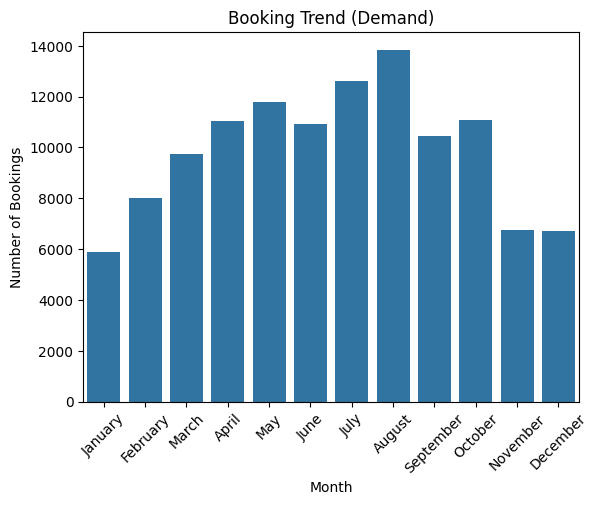

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.countplot(x='Arrival_Month', data=df_cleaned,)

plt.title('Booking Trend (Demand)')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

**Interpretation:**
- Booking demand shows clear seasonality, with peak volumes occurrin in August with 13852 booking and lower demand in January with 5874 booking. This indicates that hotel occupancy is highly dependent on seasonal travel patterns.


Cancellation Overview

In [80]:
# create new column 'cancelled'
df_cleaned['Cancelled'] = df_cleaned['is_canceled']

# cancellation trend
df_cleaned['Cancelled'].mean()

# cancellation by month
df_cleaned.groupby('Arrival_Month')['Cancelled'].mean()

df_cleaned.head(10)


/tmp/ipykernel_21561/2046196149.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cleaned.groupby('Arrival_Month')['Cancelled'].mean()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,Arrival_Date,Arrival_Month,Arrival_Weekday,Stay_Nights,Stay_Category,Booking_Urgency,Cancel_Month,Cancel_Weekday,Revenue,Cancelled
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,2015-07-01,July,Wednesday,0,Short,Early,July,Wednesday,0.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,2015-07-01,July,Wednesday,0,Short,Early,July,Wednesday,0.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,2015-07-01,July,Wednesday,1,Short,Normal,July,Thursday,75.0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,2015-07-01,July,Wednesday,1,Short,Normal,July,Thursday,75.0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2015-07-01,July,Wednesday,2,Short,Normal,July,Friday,196.0,0
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2015-07-01,July,Wednesday,2,Short,Normal,July,Friday,196.0,0
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,2015-07-01,July,Wednesday,2,Short,Last Minute,July,Friday,214.0,0
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,2015-07-01,July,Wednesday,2,Short,Normal,July,Friday,206.0,0
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,2015-07-01,July,Wednesday,3,Medium,Early,May,Wednesday,246.0,1
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,2015-07-01,July,Wednesday,3,Medium,Early,April,Wednesday,316.5,1


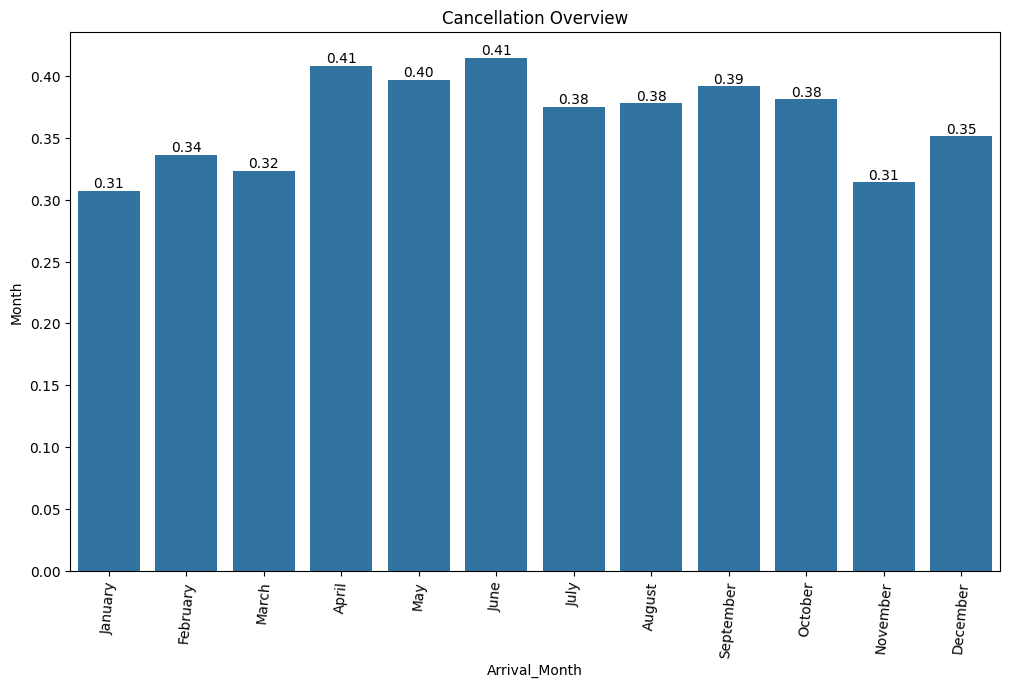

In [81]:
# visualization
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_cleaned, x='Arrival_Month', y='Cancelled', errorbar=None)

for s in ax.containers:
    ax.bar_label(s, fmt='%.2f')

plt.title('Cancellation Overview')
plt.ylabel('Month')
plt.xticks(rotation=85)

plt.show()

**Interpretation**
- Cancellation rates are highest in April & June (41%). This suggests that demand fluctuations may influence customer commitment and cancellation behavior.

Cancellation Breakdown

In [82]:
# by market segment
df_cleaned.groupby('market_segment')['Cancelled'].agg(['mean','count'])

# by distibution channel
df_cleaned.groupby('distribution_channel')['Cancelled'].agg(['mean','count'])

# by booking urgency
df_cleaned.groupby('Booking_Urgency')['Cancelled'].agg(['mean','count'])

# by guest status (repeated or not)
df_cleaned.groupby('is_repeated_guest')['Cancelled'].agg(['mean','count'])


,mean,count
is_repeated_guest,,
0,0.378836,115092
1,0.145034,3806


In [83]:
pivot = df_cleaned.pivot_table(
    values='Cancelled',
    index='market_segment',
    columns='distribution_channel',
    aggfunc='mean'
)


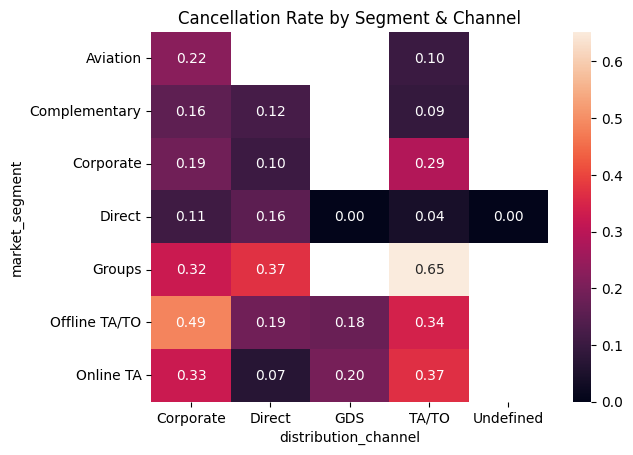

In [84]:
# visualization
import seaborn as sns

sns.heatmap(pivot, annot=True, fmt=".2f")

plt.title("Cancellation Rate by Segment & Channel")
plt.show()

Business Impact

In [85]:
# loss by revenue
df_cleaned.groupby('Cancelled')['Revenue'].sum()

,Revenue
Cancelled,
0,25908964.82
1,16711237.66


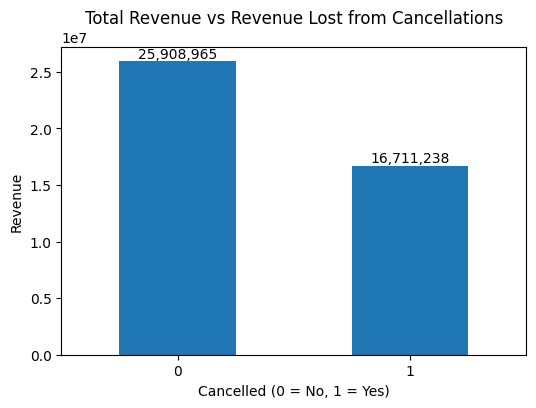

In [86]:
# visualization
import matplotlib.pyplot as plt

rev_status = df_cleaned.groupby('Cancelled')['Revenue'].sum()
plt.figure(figsize=(6,4))

ax = rev_status.plot(kind='bar')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title("Total Revenue vs Revenue Lost from Cancellations")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

In [87]:
# loss by market segment
df_cleaned[df_cleaned['Cancelled'] == 1].groupby('market_segment')['Revenue'].sum().sort_values(ascending=False)

,Revenue
market_segment,
Online TA,10227110.61
Groups,2800543.98
Offline TA/TO,2483476.35
Direct,988138.66
Corporate,195120.07
Aviation,16578.00
Complementary,269.99


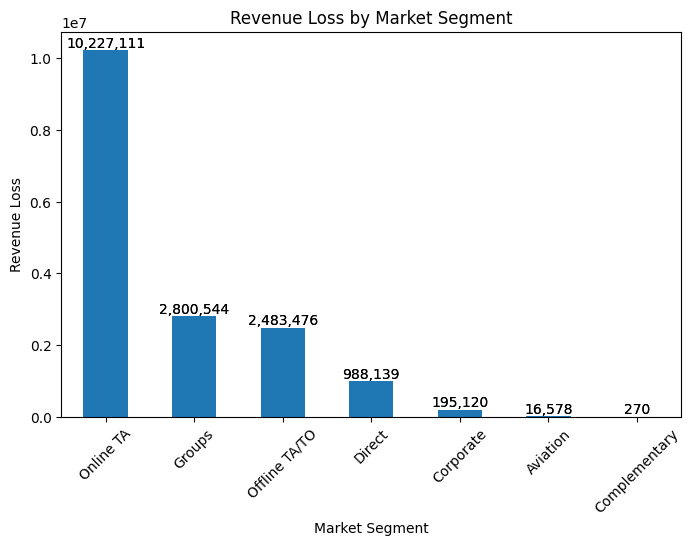

In [88]:
# visualization
loss_segment = df_cleaned[df_cleaned['Cancelled'] == 1] \
    .groupby('market_segment')['Revenue'] \
    .sum() \
    .sort_values(ascending=False)

plt.figure(figsize=(8,5))
loss_segment.plot(kind='bar')

ax = loss_segment.plot(kind='bar')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title("Revenue Loss by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Revenue Loss")
plt.xticks(rotation=45)

plt.show()

In [89]:
# # loss by distribution channel
df_cleaned[df_cleaned['Cancelled'] == 1].groupby('distribution_channel')['Revenue'].sum().sort_values(ascending=False)

,Revenue
distribution_channel,
TA/TO,15277690.70
Direct,1135441.96
Corporate,285115.54
GDS,12989.46


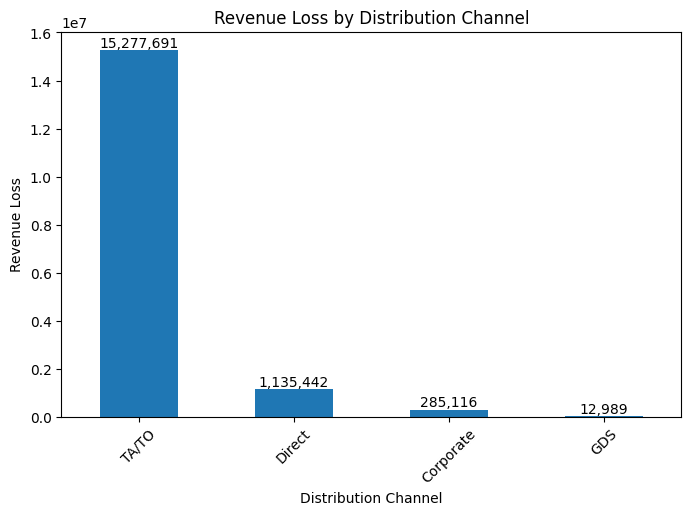

In [90]:
# visualization
loss_channel = df_cleaned[df_cleaned['Cancelled'] == 1] \
    .groupby('distribution_channel')['Revenue'] \
    .sum() \
    .sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = loss_channel.plot(kind='bar')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title("Revenue Loss by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Revenue Loss")
plt.xticks(rotation=45)

plt.show()